# 06 — Encoding Model: All Conditions + Electrode Selection

Runs Ridge Regression encoding models for **all conditions** (contextual XLM-RoBERTa
and static FastText) and evaluates performance on **language-responsive electrodes only**,
matching Eyal's analysis approach.

## Conditions
| Name | Type | Description |
|---|---|---|
| `en` | contextual | XLM-R English alone |
| `he` | contextual | XLM-R Hebrew alone |
| `ar` | contextual | XLM-R Arabic alone |
| `en+he_ft_residual` | contextual | XLM-R EN + FastText HE residual |
| `en+ar_ft_residual` | contextual | XLM-R EN + FastText AR residual |
| `noise` | contextual | noise baseline |
| `English` | static | FastText English alone |
| `Hebrew` | static | FastText Hebrew alone |
| `Arabic` | static | FastText Arabic alone |
| `English+Hebrew` | static | FastText EN+HE (Eyal) |
| `English+Arabic` | static | FastText EN+AR (Eyal) |
| `English+Hebrew_residual` | static | FastText EN + HE residual |
| `English+Arabic_residual` | static | FastText EN + AR residual |
| `English+noise` | static | noise baseline (Eyal) |

## Electrode selection
Per subject: select electrodes where peak r in the **English contextual** condition
exceeds the configurable threshold. All summary statistics use only these electrodes.

## 1. Imports

In [1]:
import sys
import os
import json
import io
import warnings
from contextlib import redirect_stdout
from datetime import datetime

sys.path.insert(0, os.path.abspath('../data/Amirim_Project_Submission'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import mne
from mne_bids import BIDSPath
from nilearn.plotting import plot_markers
from static_encoding import process_embeddings

print('Imports ready.')

Imports ready.


## 2. Load All Embeddings

In [2]:
DATA_DIR        = '../data/processed/'
WORD_LEVEL_PATH = '../data/Amirim_Project_Submission/translated_podcast_transcript_filtered.csv'
FT_PATH         = '../data/Amirim_Project_Submission/podcast_trilingual_embeddings.csv'

full_transcript = pd.read_csv(WORD_LEVEL_PATH)  # 1735 content words

# ── Contextual XLM-RoBERTa embeddings (EN ∩ HE ∩ AR intersection) ─────────────
shared_df  = pd.read_csv(DATA_DIR + 'contextual_shared_indices.csv')
shared_idx = shared_df['original_word_idx'].values  # indices into 1735-word list

en_idx_df = pd.read_csv(DATA_DIR + 'en_contextual_matched_indices.csv')
he_idx_df = pd.read_csv(DATA_DIR + 'he_contextual_matched_indices.csv')
ar_idx_df = pd.read_csv(DATA_DIR + 'ar_contextual_matched_indices.csv')

en_pos = {v: i for i, v in enumerate(en_idx_df['original_word_idx'].values)}
he_pos = {v: i for i, v in enumerate(he_idx_df['original_word_idx'].values)}
ar_pos = {v: i for i, v in enumerate(ar_idx_df['original_word_idx'].values)}

E_full = pd.read_csv(DATA_DIR + 'en_contextual_aligned_embeddings.csv').values.astype(np.float32)
H_full = pd.read_csv(DATA_DIR + 'he_contextual_aligned_embeddings.csv').values.astype(np.float32)
A_full = pd.read_csv(DATA_DIR + 'ar_contextual_aligned_embeddings.csv').values.astype(np.float32)

E_xlmr = E_full[[en_pos[i] for i in shared_idx]]
H_xlmr = H_full[[he_pos[i] for i in shared_idx]]
A_xlmr = A_full[[ar_pos[i] for i in shared_idx]]

H_xlmr_res = np.load(DATA_DIR + 'hebrew_residuals_contextual.npy').astype(np.float32)
A_xlmr_res = np.load(DATA_DIR + 'arabic_residuals_contextual.npy').astype(np.float32)

ctx_word_df = full_transcript.iloc[shared_idx][['start','end']].reset_index(drop=True)

# ── FastText static embeddings (all 1735 words) ────────────────────────────────
def parse_embedding(x):
    if isinstance(x, str):
        x = x.replace('[','').replace(']','')
        return np.array(x.split(), dtype=np.float32)
    return np.array(x, dtype=np.float32)

ft_df = pd.read_csv(FT_PATH)
E_ft  = np.vstack(ft_df['en_embedding'].apply(parse_embedding).values)
H_ft  = np.vstack(ft_df['he_embedding'].apply(parse_embedding).values)
A_ft  = np.vstack(ft_df['ar_embedding'].apply(parse_embedding).values)

H_ft_res = np.load(DATA_DIR + 'fasttext_hebrew_residuals.npy').astype(np.float32)
A_ft_res = np.load(DATA_DIR + 'fasttext_arabic_residuals.npy').astype(np.float32)

static_word_df = full_transcript[['start','end']].reset_index(drop=True)

print(f'XLM-R words (shared): {len(shared_idx)}')
print(f'  E_xlmr : {E_xlmr.shape}  H_xlmr : {H_xlmr.shape}  A_xlmr : {A_xlmr.shape}')
print(f'FastText words       : {len(E_ft)}')
print(f'  E_ft   : {E_ft.shape}  H_ft   : {H_ft.shape}  A_ft   : {A_ft.shape}')
print('\nAll embeddings loaded ✓')

XLM-R words (shared): 1689
  E_xlmr : (1689, 768)  H_xlmr : (1689, 768)  A_xlmr : (1689, 768)
FastText words       : 1735
  E_ft   : (1735, 150)  H_ft   : (1735, 150)  A_ft   : (1735, 150)

All embeddings loaded ✓


## 3. Define All Conditions

In [ ]:
freq       = 64
tmin, tmax = -2.0, 2.0
use_PCA    = True
PCA_dim    = 150
subjects   = [f'{i:02d}' for i in range(1, 10)]

ctx_outpath    = f'../results/encoding_results_{freq}Hz_({tmin},{tmax})/contextual/'
static_outpath = f'../results/encoding_results_static_{freq}Hz_({tmin},{tmax})/'
os.makedirs(ctx_outpath, exist_ok=True)
os.makedirs(static_outpath, exist_ok=True)

# Format: (name, language_mode, en_mat, he_mat, ar_mat, word_df, out_folder)
ctx_base    = pd.DataFrame({'start': ctx_word_df['start'].values,    'end': ctx_word_df['end'].values})
static_base = pd.DataFrame({'start': static_word_df['start'].values, 'end': static_word_df['end'].values})

CONDITIONS = [
    # ── Contextual (XLM-RoBERTa) ──────────────────────────────────────────────
    ('en',                   'en',    E_xlmr, H_xlmr,    A_xlmr,    ctx_base,    ctx_outpath),
    ('he',                   'he',    E_xlmr, H_xlmr,    A_xlmr,    ctx_base,    ctx_outpath),
    ('ar',                   'ar',    E_xlmr, H_xlmr,    A_xlmr,    ctx_base,    ctx_outpath),
    ('en+he_ft_residual',    'en+he', E_xlmr, H_ft_res[shared_idx], A_xlmr, ctx_base, ctx_outpath),
    ('en+ar_ft_residual',    'en+ar', E_xlmr, H_xlmr,    A_ft_res[shared_idx], ctx_base, ctx_outpath),
    ('noise',                'noise', E_xlmr, H_xlmr,    A_xlmr,    ctx_base,    ctx_outpath),
    # ── Static (FastText) ─────────────────────────────────────────────────────
    ('English',              'en',    E_ft,   H_ft,      A_ft,      static_base, static_outpath),
    ('Hebrew',               'he',    E_ft,   H_ft,      A_ft,      static_base, static_outpath),
    ('Arabic',               'ar',    E_ft,   H_ft,      A_ft,      static_base, static_outpath),
    ('English+Hebrew',       'en+he', E_ft,   H_ft,      A_ft,      static_base, static_outpath),
    ('English+Arabic',       'en+ar', E_ft,   H_ft,      A_ft,      static_base, static_outpath),
    ('English+Hebrew_residual','en+he',E_ft,  H_ft_res,  A_ft,      static_base, static_outpath),
    ('English+Arabic_residual','en+ar',E_ft,  H_ft,      A_ft_res,  static_base, static_outpath),
    ('English+noise',        'noise', E_ft,   H_ft,      A_ft,      static_base, static_outpath),
]

print(f'Total conditions : {len(CONDITIONS)}')
print(f'Total runs       : {len(subjects)} x {len(CONDITIONS)} = {len(subjects)*len(CONDITIONS)}')
print()
print(f'Output paths:')
print(f'  Contextual : {ctx_outpath}')
print(f'  Static     : {static_outpath}')
print()
print(f'{"Name":28s}  {"Type":10s}  {"Words":>6s}  {"Dim"}')
print('-' * 65)
for name, mode, en, he, ar, base, folder in CONDITIONS:
    t = 'contextual' if folder == ctx_outpath else 'static'
    print(f'{name:28s}  {t:10s}  {len(base):>6d}  en={en.shape[1]}d he={he.shape[1]}d ar={ar.shape[1]}d')

## 4. Encoding Loop (skip if already saved)

In [ ]:
for subj in subjects:
    file_path = BIDSPath(
        root='../data/ds005574/derivatives/ecogprep',
        subject=subj, task='podcast', datatype='ieeg',
        description='highgamma', suffix='ieeg', extension='.fif'
    ).fpath
    fif_path = str(file_path)
    if not os.path.exists(fif_path):
        print(f'Subject {subj}: file not found, skipping.')
        continue

    pending = [
        c for c in CONDITIONS
        if not os.path.exists(os.path.join(c[6], f'corrs subj={subj} - {c[0]}.npy'))
    ]
    if not pending:
        print(f'Subject {subj}: all {len(CONDITIONS)} conditions already saved, skipping.')
        continue

    raw = mne.io.read_raw_fif(fif_path, verbose=False)
    print(f'\nSubject {subj}: {len(raw.info["ch_names"])} channels | {len(pending)}/{len(CONDITIONS)} to run')

    for name, mode, en_mat, he_mat, ar_mat, base_df, outpath in tqdm(pending, desc=f'Subj {subj}'):
        embedding_df = base_df.copy()
        embedding_df['en_embedding'] = list(en_mat.astype(np.float32))
        embedding_df['he_embedding'] = list(he_mat.astype(np.float32))
        embedding_df['ar_embedding'] = list(ar_mat.astype(np.float32))

        f = io.StringIO()
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            with redirect_stdout(f):
                _, cv_scores = process_embeddings(
                    embedding_df=embedding_df, raw=raw,
                    channel_names_regex='', freq=freq,
                    tmin=tmin, tmax=tmax, language_mode=mode,
                    random_noise_mode='over all embeds',
                    use_PCA=use_PCA, PCA_dim=PCA_dim
                )

        np.save(os.path.join(outpath, f'corrs subj={subj} - {name}.npy'), cv_scores)

print('\nEncoding loop complete.')

## 5. Electrode Selection

For each subject, select electrodes where the peak r in the **English contextual**
condition exceeds a threshold. All subsequent analysis uses only these electrodes.

This matches Eyal's approach and the original paper's analysis.

In [4]:
# ── Config ────────────────────────────────────────────────────────────────────
# Electrode selection is based on the English contextual condition.
# Two options (set SELECTION_MODE):
#   'percentile' — top PERCENTILE% of electrodes by peak r
#   'threshold'  — electrodes where peak r >= THRESHOLD
SELECTION_MODE = 'threshold'  # 'percentile' or 'threshold'
PERCENTILE     = 75    # top 25% of electrodes
THRESHOLD      = 0.1  # used if SELECTION_MODE = 'threshold'

selected_electrodes = {}   # subj -> array of electrode indices

print(f'Electrode selection: {SELECTION_MODE}'
      f'{" (top " + str(100-PERCENTILE) + "%)" if SELECTION_MODE=="percentile" else " (r >= " + str(THRESHOLD) + ")"}')
print()
print(f'{"Subj":>6s}  {"Total elec":>10s}  {"Selected":>10s}  {"% selected":>10s}  {"Threshold r":>12s}')
print('-' * 55)

for subj in subjects:
    en_fname = os.path.join(ctx_outpath, f'corrs subj={subj} - en.npy')
    if not os.path.exists(en_fname):
        print(f'{subj:>6s}  English contextual scores not found, skipping.')
        continue

    scores = np.load(en_fname)              # (n_folds, n_electrodes, n_timepoints)
    peak_r = scores.mean(0).max(-1)         # (n_electrodes,) — peak r per electrode

    if SELECTION_MODE == 'percentile':
        thresh = np.percentile(peak_r, PERCENTILE)
    else:
        thresh = THRESHOLD

    selected = np.where(peak_r >= thresh)[0]
    selected_electrodes[subj] = selected

    print(f'{subj:>6s}  {len(peak_r):>10d}  {len(selected):>10d}  '
          f'{len(selected)/len(peak_r)*100:>9.1f}%  {thresh:>12.4f}')

Electrode selection: threshold (r >= 0.1)

  Subj  Total elec    Selected  % selected   Threshold r
-------------------------------------------------------
    01          99          61       61.6%        0.1000
    02          90          38       42.2%        0.1000
    03         235         113       48.1%        0.1000
    04         143          87       60.8%        0.1000
    05         159          74       46.5%        0.1000
    06         166          87       52.4%        0.1000
    07         116          31       26.7%        0.1000
    08          72          40       55.6%        0.1000
    09         188         104       55.3%        0.1000


## 6. Time-Lag Plots (selected electrodes only)

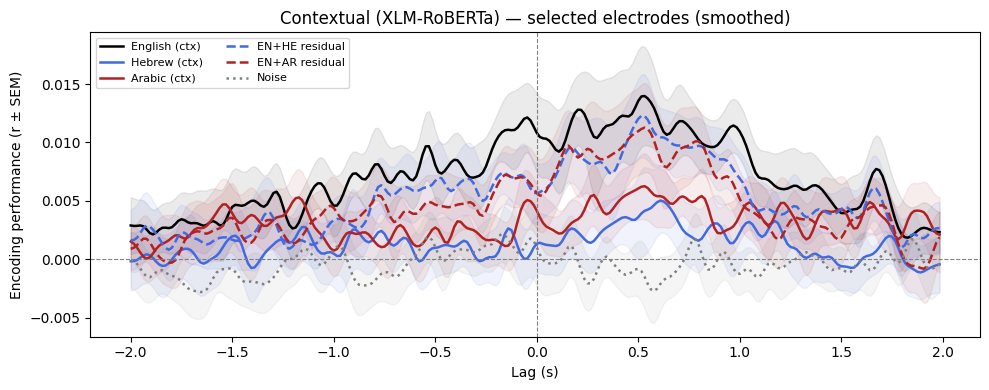

Saved: ../results/contextual_xlmr_r0p1_smoothed.png


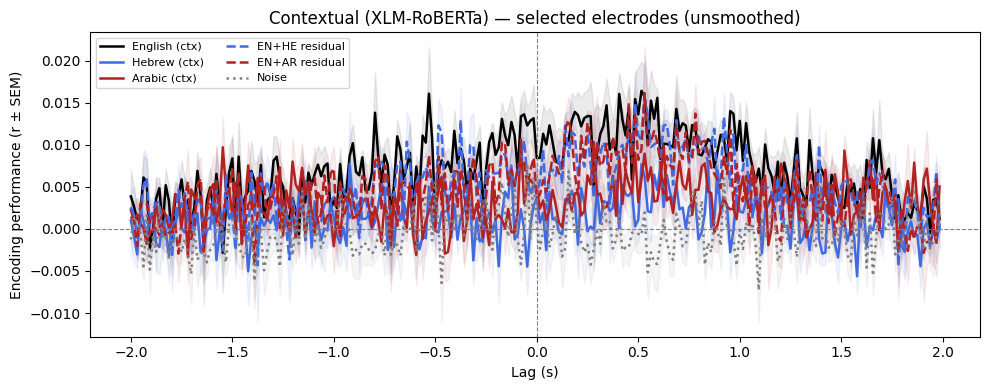

Saved: ../results/contextual_xlmr_r0p1_unsmoothed.png


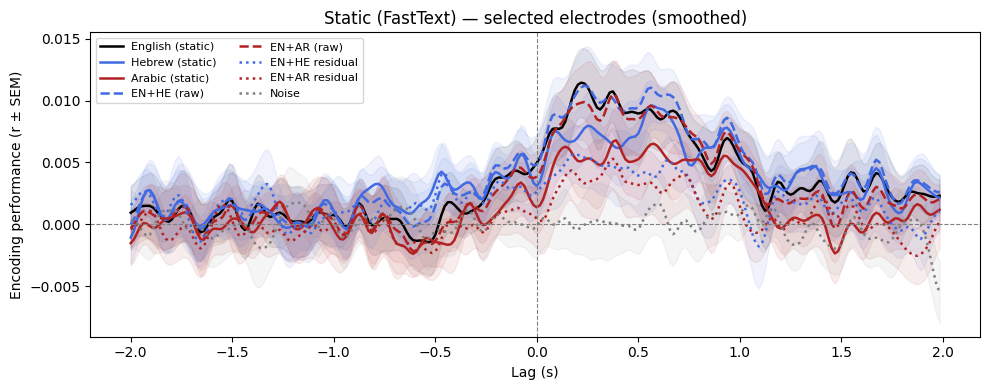

Saved: ../results/static_fasttext_r0p1_smoothed.png


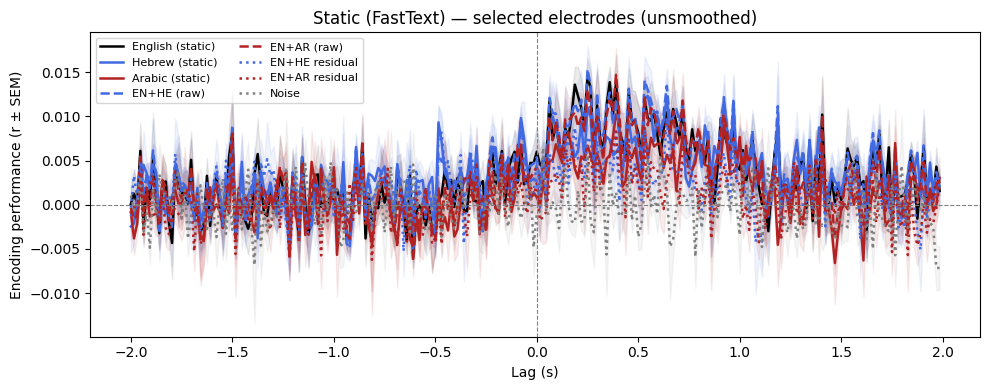

Saved: ../results/static_fasttext_r0p1_unsmoothed.png

Per-subject: English contextual vs static vs noise


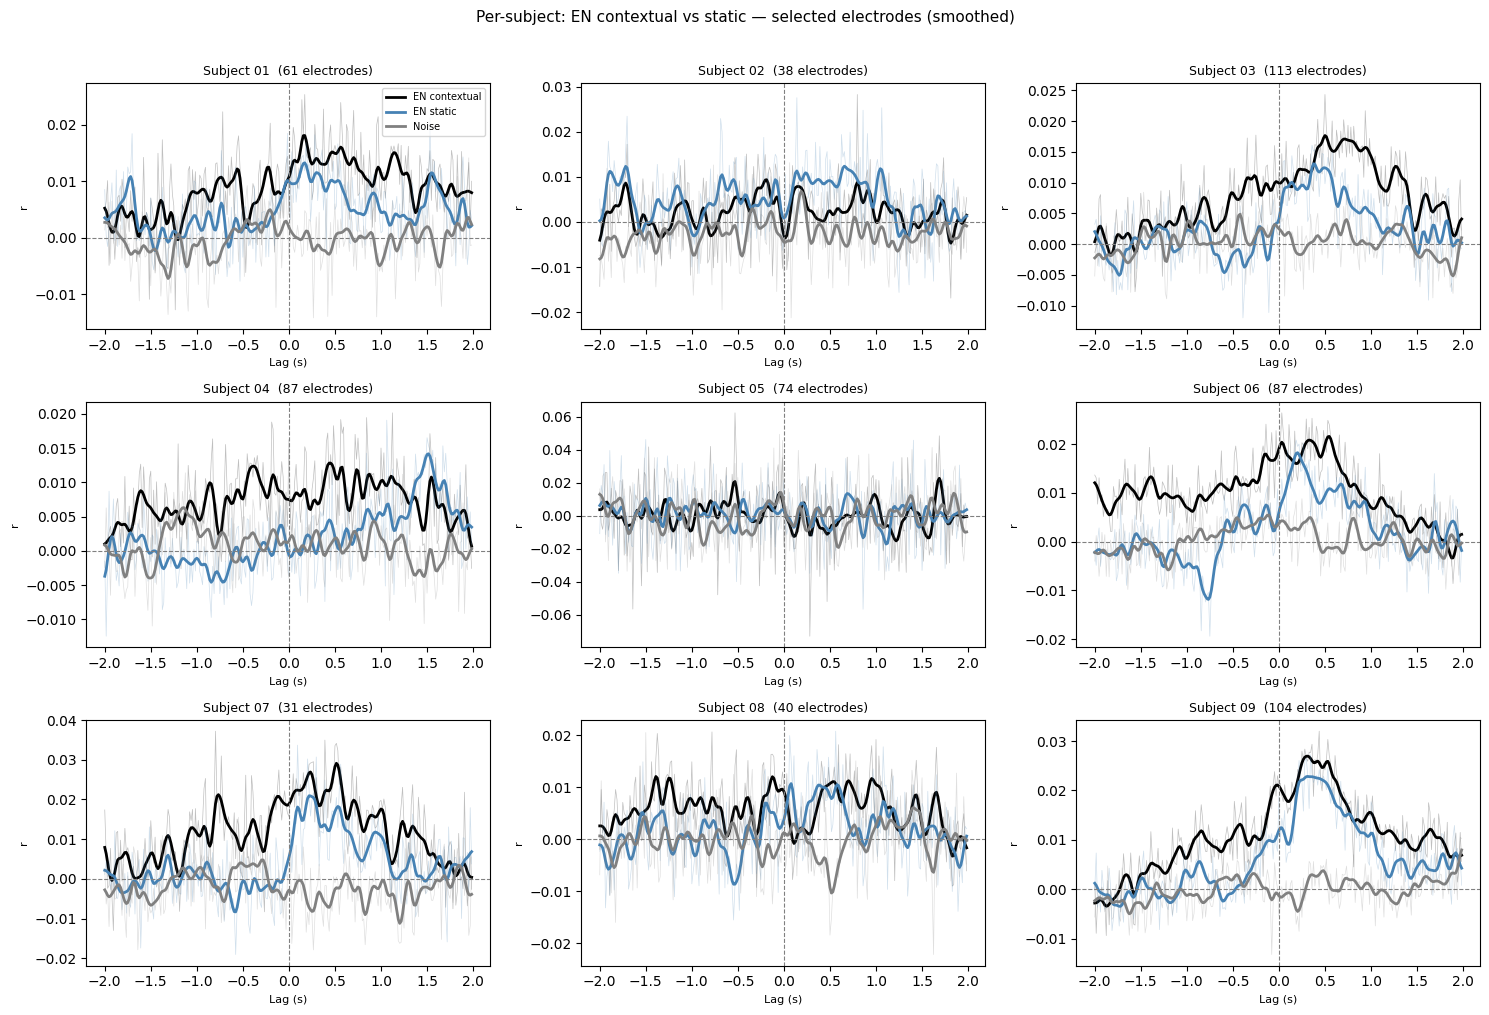

Saved: ../results/per_subject_en_ctx_vs_static_r0p1_smoothed.png


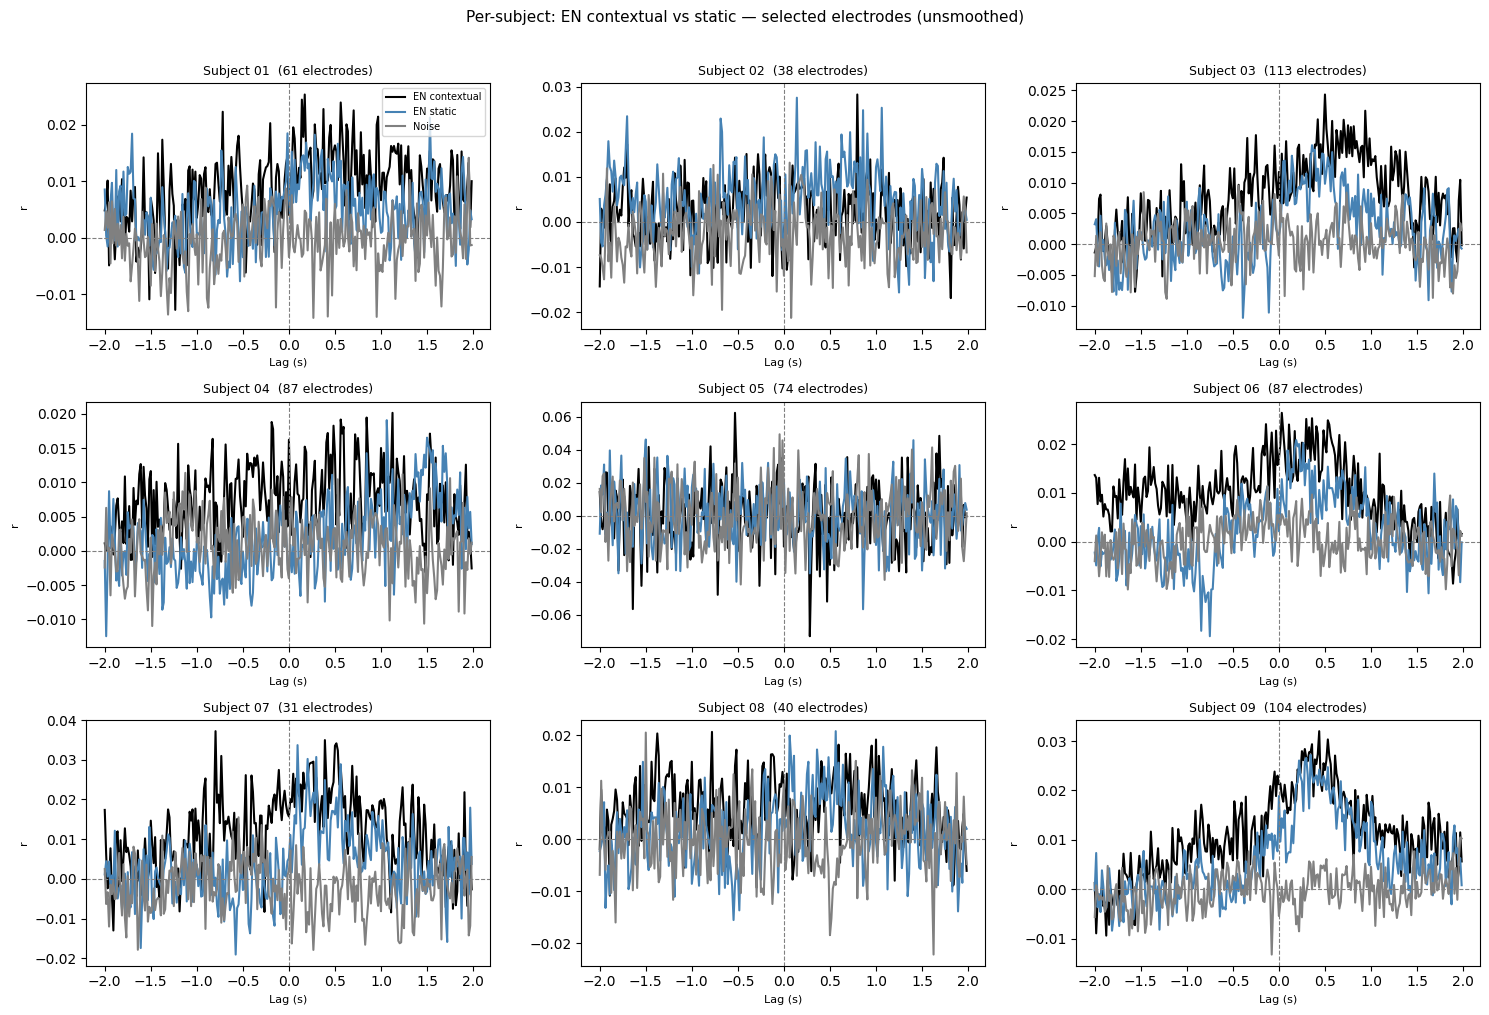

Saved: ../results/per_subject_en_ctx_vs_static_r0p1_unsmoothed.png

All plots saved to: /Users/YAHLIZ/Desktop/Language-Project-main/results


In [7]:
from scipy.ndimage import gaussian_filter1d

lags = np.arange(tmin * 512, tmax * 512, (512 / freq)) / 512
SMOOTH_SIGMA = 2   # Gaussian smoothing — increase for smoother, decrease for more detail

# ── Results folder ─────────────────────────────────────────────────────────────
RESULTS_DIR = '../results/'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Tag for filenames based on electrode selection config
sel_tag = (f'top{100-PERCENTILE}pct' if SELECTION_MODE == 'percentile'
           else f'r{str(THRESHOLD).replace(".","p")}')

def load_curve(folder, cond_name, subj):
    """Mean time-lag curve over selected electrodes for one subject."""
    fname = os.path.join(folder, f'corrs subj={subj} - {cond_name}.npy')
    if not os.path.exists(fname) or subj not in selected_electrodes:
        return None
    scores = np.load(fname)              # (folds, electrodes, time)
    sel    = selected_electrodes[subj]
    if len(sel) == 0:
        return None
    return scores.mean(0)[sel].mean(0)  # (n_timepoints,)

def plot_grand_avg(group, smooth):
    """Plot grand-average time-lag curves, with or without Gaussian smoothing."""
    fig, ax = plt.subplots(figsize=(10, 4))
    for cond_name, label, color, ls in group['conditions']:
        curves = [load_curve(group['folder'], cond_name, s) for s in subjects]
        curves = [c for c in curves if c is not None]
        if not curves:
            continue
        grand_mean = np.mean(curves, axis=0)
        grand_sem  = np.std(curves, axis=0) / np.sqrt(len(curves))
        if smooth:
            y    = gaussian_filter1d(grand_mean, SMOOTH_SIGMA)
            y_lo = gaussian_filter1d(grand_mean - grand_sem, SMOOTH_SIGMA)
            y_hi = gaussian_filter1d(grand_mean + grand_sem, SMOOTH_SIGMA)
        else:
            y, y_lo, y_hi = grand_mean, grand_mean - grand_sem, grand_mean + grand_sem
        ax.plot(lags, y, color=color, ls=ls, lw=1.8, label=label)
        ax.fill_between(lags, y_lo, y_hi, color=color, alpha=0.08)

    ax.axvline(0, color='gray', ls='--', lw=0.8)
    ax.axhline(0, color='gray', ls='--', lw=0.8)
    ax.set_xlabel('Lag (s)')
    ax.set_ylabel('Encoding performance (r ± SEM)')
    ax.set_title(group['title'] + (' (smoothed)' if smooth else ' (unsmoothed)'))
    ax.legend(fontsize=8, loc='upper left', ncol=2)
    plt.tight_layout()
    return fig

# ── 1. Grand-average plots — smoothed AND unsmoothed ──────────────────────────
PLOT_GROUPS = [
    {
        'title': 'Contextual (XLM-RoBERTa) — selected electrodes',
        'slug':  'contextual_xlmr',
        'conditions': [
            ('en',                'English (ctx)',   'black',     '-'),
            ('he',                'Hebrew (ctx)',    'royalblue', '-'),
            ('ar',                'Arabic (ctx)',    'firebrick', '-'),
            ('en+he_ft_residual', 'EN+HE residual', 'royalblue', '--'),
            ('en+ar_ft_residual', 'EN+AR residual', 'firebrick', '--'),
            ('noise',             'Noise',           'gray',      ':'),
        ],
        'folder': ctx_outpath,
    },
    {
        'title': 'Static (FastText) — selected electrodes',
        'slug':  'static_fasttext',
        'conditions': [
            ('English',                 'English (static)',  'black',     '-'),
            ('Hebrew',                  'Hebrew (static)',   'royalblue', '-'),
            ('Arabic',                  'Arabic (static)',   'firebrick', '-'),
            ('English+Hebrew',          'EN+HE (raw)',       'royalblue', '--'),
            ('English+Arabic',          'EN+AR (raw)',       'firebrick', '--'),
            ('English+Hebrew_residual', 'EN+HE residual',   'royalblue', ':'),
            ('English+Arabic_residual', 'EN+AR residual',   'firebrick', ':'),
            ('English+noise',           'Noise',             'gray',      ':'),
        ],
        'folder': static_outpath,
    },
]

for group in PLOT_GROUPS:
    for smooth in [True, False]:
        fig = plot_grand_avg(group, smooth=smooth)
        variant = 'smoothed' if smooth else 'unsmoothed'
        fname = os.path.join(RESULTS_DIR, f'{group["slug"]}_{sel_tag}_{variant}.png')
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved: {fname}')

# ── 2. Per-subject: English contextual vs static vs noise ─────────────────────
print('\nPer-subject: English contextual vs static vs noise')

for smooth in [True, False]:
    fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharey=False)
    axes = axes.flatten()

    for i, subj in enumerate(subjects):
        ax = axes[i]
        for cond_name, label, color, folder in [
            ('en',      'EN contextual', 'black',     ctx_outpath),
            ('English', 'EN static',     'steelblue', static_outpath),
            ('noise',   'Noise',         'gray',      ctx_outpath),
        ]:
            curve = load_curve(folder, cond_name, subj)
            if curve is None:
                continue
            if smooth:
                ax.plot(lags, curve,                                 color=color, lw=0.5, alpha=0.25)
                ax.plot(lags, gaussian_filter1d(curve, SMOOTH_SIGMA), color=color, lw=2.0, label=label)
            else:
                ax.plot(lags, curve, color=color, lw=1.5, label=label)

        n_sel = len(selected_electrodes.get(subj, []))
        ax.axvline(0, color='gray', ls='--', lw=0.8)
        ax.axhline(0, color='gray', ls='--', lw=0.8)
        ax.set_title(f'Subject {subj}  ({n_sel} electrodes)', fontsize=9)
        ax.set_xlabel('Lag (s)', fontsize=8)
        ax.set_ylabel('r', fontsize=8)
        if i == 0:
            ax.legend(fontsize=7)

    variant = 'smoothed' if smooth else 'unsmoothed'
    plt.suptitle(f'Per-subject: EN contextual vs static — selected electrodes ({variant})',
                 fontsize=11, y=1.01)
    plt.tight_layout()
    fname = os.path.join(RESULTS_DIR, f'per_subject_en_ctx_vs_static_{sel_tag}_{variant}.png')
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

print(f'\nAll plots saved to: {os.path.abspath(RESULTS_DIR)}')

## 7. Full Summary Table (selected electrodes)

In [6]:
def mean_peak_selected(folder, cond_name):
    """Mean peak r across subjects, computed only on selected electrodes."""
    peaks = []
    for subj in subjects:
        fname = os.path.join(folder, f'corrs subj={subj} - {cond_name}.npy')
        if not os.path.exists(fname) or subj not in selected_electrodes:
            continue
        scores = np.load(fname)                      # (folds, electrodes, time)
        sel    = selected_electrodes[subj]
        peak   = scores.mean(0)[sel].max(-1).mean()  # mean peak r over selected elecs
        peaks.append(peak)
    return np.mean(peaks) if peaks else float('nan')

# Matched pairs: (label, contextual_name/None, static_name/None)
PAIRS = [
    ('EN alone',        'en',                 'English'),
    ('HE alone',        'he',                 'Hebrew'),
    ('AR alone',        'ar',                 'Arabic'),
    ('EN+HE (raw)',     None,                 'English+Hebrew'),
    ('EN+AR (raw)',     None,                 'English+Arabic'),
    ('EN+HE residual',  'en+he_ft_residual',  'English+Hebrew_residual'),
    ('EN+AR residual',  'en+ar_ft_residual',  'English+Arabic_residual'),
    ('Noise',           'noise',              'English+noise'),
]

ctx_noise    = mean_peak_selected(ctx_outpath,    'noise')
static_noise = mean_peak_selected(static_outpath, 'English+noise')

print('=' * 78)
print(f'FULL COMPARISON — selected electrodes ({SELECTION_MODE}, '
      f'{"top " + str(100-PERCENTILE) + "%" if SELECTION_MODE=="percentile" else "r>=" + str(THRESHOLD)})')
print('=' * 78)
print(f'{"Condition":<20s}  {"Contextual":>12s}  {"vs noise":>9s}  '
      f'{"Static":>10s}  {"vs noise":>9s}  {"CTX-STA":>8s}')
print('-' * 78)

for label, ctx_name, static_name in PAIRS:
    ctx_r    = mean_peak_selected(ctx_outpath,    ctx_name)    if ctx_name    else float('nan')
    static_r = mean_peak_selected(static_outpath, static_name) if static_name else float('nan')

    ctx_gap    = ctx_r    - ctx_noise    if not np.isnan(ctx_r)    else float('nan')
    static_gap = static_r - static_noise if not np.isnan(static_r) else float('nan')
    delta      = ctx_r - static_r        if not (np.isnan(ctx_r) or np.isnan(static_r)) else float('nan')

    def fmt(v): return f'{v:.4f}' if not np.isnan(v) else '  —   '
    def fmtd(v): return f'{v:+.4f}' if not np.isnan(v) else '  —   '

    print(f'{label:<20s}  {fmt(ctx_r):>12s}  {fmtd(ctx_gap):>9s}  '
          f'{fmt(static_r):>10s}  {fmtd(static_gap):>9s}  {fmtd(delta):>8s}')

print()
print(f'Noise baselines  — contextual: {ctx_noise:.4f}  |  static: {static_noise:.4f}')

FULL COMPARISON — selected electrodes (threshold, r>=0.1)
Condition               Contextual   vs noise      Static   vs noise   CTX-STA
------------------------------------------------------------------------------
EN alone                    0.1167    +0.0217      0.1006    +0.0054   +0.0161
HE alone                    0.0999    +0.0048      0.0986    +0.0033   +0.0013
AR alone                    0.1018    +0.0067      0.0954    +0.0002   +0.0063
EN+HE (raw)                   —          —         0.1010    +0.0058      —   
EN+AR (raw)                   —          —         0.0993    +0.0041      —   
EN+HE residual              0.1036    +0.0085      0.0982    +0.0030   +0.0054
EN+AR residual              0.1043    +0.0092      0.0968    +0.0015   +0.0075
Noise                       0.0951    +0.0000      0.0952    +0.0000   -0.0002

Noise baselines  — contextual: 0.0951  |  static: 0.0952
